# Program-Level Student Enrollment Forecasting
## Connecting Google search demand, website behavior, leads, applications, and enrollment

This case study develops a leakage-aware machine-learning workflow for forecasting **weekly enrollment by academic program four weeks ahead**. It connects the complete recruitment funnel:

**Google keyword search volume → impressions/clicks → website sessions and program-page engagement → inquiry forms and leads → applications/admissions → enrollments**

### Business objective

Admissions and marketing teams need an earlier view of program demand so they can adjust media, counselor capacity, class sections, faculty planning, and enrollment targets before census dates.

> Funnel data is observational. Search, website behavior, and leads can predict enrollment without proving that additional advertising will cause additional enrollment. Budget changes require incrementality testing.

### What this notebook demonstrates

- A precise forecast target, observation cutoff, horizon, and program-week grain
- Synthetic but realistic search, media, GA4-style behavior, CRM funnel, and enrollment data
- Source integration, data contracts, quality checks, EDA, funnel analysis, and lag design
- Staged feature-set experiments showing the value of upper-, mid-, and lower-funnel signals
- Naive, Ridge, Random Forest, and gradient-boosted regression models
- Expanding-window validation and hyperparameter tuning without future leakage
- MAE, RMSE, R², WAPE, bias, interval coverage, and per-program diagnostics
- Business outcomes: planning accuracy, target attainment, capacity risk, and value of earlier warning
- Interpretation, deployment, monitoring, retraining, governance, and experimentation

## 1. Setup

In [1]:
from pathlib import Path
from time import perf_counter
import json, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
COLORS=["#2563eb","#7c3aed","#0f766e","#d97706","#dc2626"]
RANDOM_STATE=42
rng=np.random.default_rng(RANDOM_STATE)

mkdir -p failed for path C:\Users\jacob\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jacob\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jacob\AppData\Local\Temp\matplotlib-8fdgcxhd because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## 2. Define the Prediction Problem

| Component | Definition |
|---|---|
| Decision | Program-level marketing, counselor, and class-capacity planning |
| Grain | One academic program × observation week |
| Target | Students who enroll in that program during week `t + 4` |
| Forecast horizon | Four weeks after the observation cutoff |
| Available signals | Search, media, website, lead, and application activity observed through week `t` |
| Excluded leakage | Admission/enrollment events after week `t`, future media, and fields updated after outcome |
| Refresh | Weekly |

The four-week horizon creates action time. A same-week enrollment model might be more accurate but less useful because staffing and media changes cannot take effect immediately.

In [2]:
problem={
    "grain":"program_id × observation_week",
    "target":"enrollments four weeks after observation week",
    "horizon_weeks":4,
    "refresh":"weekly",
    "technical_gates":{"WAPE":"< 25%","bias":"between -5% and +5%","interval_coverage":"75%–85%"},
    "business_gates":{"planning_error_reduction":"> 10% vs seasonal baseline","capacity_risk":"reduced"},
}
display(pd.Series(problem,name="definition").to_frame())

,definition
grain,program_id × observation_week
target,enrollments four weeks after observation week
horizon_weeks,4
refresh,weekly
technical_gates,"{'WAPE': '< 25%', 'bias': 'between -5% and +5%..."
business_gates,{'planning_error_reduction': '> 10% vs seasona...


## 3. Source Systems and Data Contract

- **Google Trends / Keyword Planner:** branded and non-branded program keyword search volume—an upper-funnel indicator of market demand.
- **Google Ads / Search Console:** impressions, clicks, cost, average position, and query-program mapping.
- **GA4 / web analytics:** sessions, engaged sessions, program-page views, return visits, CTA clicks, and form starts.
- **CRM:** inquiry leads, qualified leads, applications, admits, and stage timestamps.
- **Student information system:** deposits, enrollments, starts, cancellations, and program/campus reference data.

Use stable `program_id` and calendar-week keys. Query-level traffic needs a governed mapping to programs. Snapshot mutable CRM stages so the training set reflects what was known at each historical cutoff.

In [3]:
programs=pd.DataFrame({
    "program_id":["BS-DS","MS-DA","MBA","BS-NUR","MS-CS","BA-PSY","BS-CYB","MA-ED"],
    "program_name":["B.S. Data Science","M.S. Data Analytics","MBA","B.S. Nursing",
                    "M.S. Computer Science","B.A. Psychology","B.S. Cybersecurity","M.A. Education"],
    "level":["Undergraduate","Graduate","Graduate","Undergraduate","Graduate","Undergraduate","Undergraduate","Graduate"],
    "annual_tuition":[28000,24500,31000,30000,26000,25000,28500,22000],
    "weekly_capacity":[18,15,22,20,16,19,15,17],
    "base_demand":[1.05,1.20,1.35,1.18,1.26,.88,1.10,.94],
})
weeks=pd.date_range("2023-01-02","2026-06-29",freq="W-MON")
panel=pd.MultiIndex.from_product([weeks,programs.program_id],names=["week","program_id"]).to_frame(index=False)
panel=panel.merge(programs,on="program_id",validate="many_to_one")
assert not panel.duplicated(["week","program_id"]).any()
print(f"Program-week rows: {len(panel):,} | Programs: {panel.program_id.nunique()} | Weeks: {panel.week.nunique()}")

Program-week rows: 1,464 | Programs: 8 | Weeks: 183


## 4. Generate the Recruitment Funnel

The simulation preserves realistic dependencies: search affects impressions, clicks feed sessions, engaged visitors start forms, leads become applications, admits become enrollments, and every stage has program and seasonal variation. Random variation ensures the problem is not deterministic.

In [4]:
week_num=((panel.week-panel.week.min()).dt.days/7).astype(int)
season=1+.24*np.sin(2*np.pi*(panel.week.dt.isocalendar().week.astype(int)-4)/52)
fall_push=1+.38*panel.week.dt.month.isin([7,8,9]).astype(int)
trend=1+.0022*week_num
competitive=panel.program_id.map({"BS-DS":1.15,"MS-DA":1.20,"MBA":1.28,"BS-NUR":.95,
                                  "MS-CS":1.25,"BA-PSY":.82,"BS-CYB":1.10,"MA-ED":.86})

panel["keyword_search_volume"]=rng.poisson(720*panel.base_demand*competitive*season*fall_push*trend)
panel["branded_search_share"]=np.clip(rng.normal(.28+0.03*panel.base_demand,.035,len(panel)),.12,.48)
panel["google_impressions"]=rng.poisson(panel.keyword_search_volume*1.7)
panel["paid_search_spend"]=panel.google_impressions*rng.uniform(.035,.075,len(panel))
panel["google_clicks"]=rng.binomial(panel.google_impressions.astype(int),np.clip(.045+.035*panel.branded_search_share,0,.15))
panel["organic_clicks"]=rng.poisson(panel.keyword_search_volume*(.055+.08*panel.branded_search_share))
panel["website_sessions"]=panel.google_clicks+panel.organic_clicks+rng.poisson(42*panel.base_demand,len(panel))
engagement_rate=np.clip(.48+.06*panel.branded_search_share+rng.normal(0,.035,len(panel)),.28,.75)
panel["engaged_sessions"]=rng.binomial(panel.website_sessions.astype(int),engagement_rate)
panel["program_page_views"]=rng.poisson(panel.engaged_sessions*1.65)
panel["return_visitors"]=rng.binomial(panel.website_sessions.astype(int),np.clip(.18+.10*panel.branded_search_share,0,.5))
panel["form_starts"]=rng.binomial(panel.engaged_sessions.astype(int),np.clip(.075+.025*panel.base_demand,0,.25))
panel["leads"]=rng.binomial(panel.form_starts.astype(int),np.clip(.70+rng.normal(0,.025,len(panel)),.5,.9))
panel["qualified_leads"]=rng.binomial(panel.leads.astype(int),np.clip(.48+.10*panel.branded_search_share,0,.8))
panel["applications"]=rng.binomial(panel.qualified_leads.astype(int),np.clip(.38+.08*panel.base_demand,0,.75))
panel["admits"]=rng.binomial(panel.applications.astype(int),panel.program_id.map({
    "BS-DS":.72,"MS-DA":.68,"MBA":.75,"BS-NUR":.58,"MS-CS":.64,"BA-PSY":.80,"BS-CYB":.74,"MA-ED":.78}))
yield_rate=panel.program_id.map({"BS-DS":.42,"MS-DA":.50,"MBA":.45,"BS-NUR":.58,
                                "MS-CS":.48,"BA-PSY":.38,"BS-CYB":.44,"MA-ED":.52})
panel["enrollments"]=rng.binomial(panel.admits.astype(int),yield_rate)
display(panel.head(3))

,week,program_id,program_name,level,annual_tuition,weekly_capacity,base_demand,keyword_search_volume,branded_search_share,google_impressions,...,website_sessions,engaged_sessions,program_page_views,return_visitors,form_starts,leads,qualified_leads,applications,admits,enrollments
0,2023-01-02,BS-DS,B.S. Data Science,Undergraduate,28000,18,1.05,819,0.346818,1362,...,174,84,148,33,6,5,4,1,1,0
1,2023-01-02,MS-DA,M.S. Data Analytics,Graduate,24500,15,1.20,986,0.268439,1692,...,238,113,189,50,9,5,3,2,2,2
2,2023-01-02,MBA,MBA,Graduate,31000,22,1.35,1165,0.358064,1946,...,247,133,216,50,9,6,4,2,1,1


## 5. Data Integration and Quality Checks

At program-week grain, validate uniqueness, completeness, nonnegative funnel counts, stage ordering, and source freshness. Funnel ordering rules such as `applications ≤ qualified_leads ≤ leads` catch mapping or snapshot failures. Anomaly checks should distinguish genuine campaign spikes from ingestion defects.

In [5]:
# Inject a few defects to demonstrate validation and cleaning.
panel.loc[rng.choice(panel.index,12,replace=False),"website_sessions"]=np.nan
panel.loc[rng.choice(panel.index,5,replace=False),"paid_search_spend"]=-10

quality=pd.Series({
    "duplicate_program_weeks":panel.duplicated(["week","program_id"]).sum(),
    "missing_sessions":panel.website_sessions.isna().sum(),
    "negative_spend":panel.paid_search_spend.lt(0).sum(),
    "applications_gt_leads":panel.applications.gt(panel.leads).sum(),
    "enrollments_gt_admits":panel.enrollments.gt(panel.admits).sum(),
    "latest_week":str(panel.week.max().date()),
})
display(quality.to_frame("result"))

panel["sessions_missing"]=panel.website_sessions.isna().astype(int)
panel["website_sessions"]=panel.groupby([panel.program_id,panel.week.dt.month]).website_sessions.transform(lambda s:s.fillna(s.median()))
panel.loc[panel.paid_search_spend.lt(0),"paid_search_spend"]=0
assert panel.website_sessions.notna().all() and panel.paid_search_spend.ge(0).all()

,result
duplicate_program_weeks,0
missing_sessions,12
negative_spend,5
applications_gt_leads,0
enrollments_gt_admits,0
latest_week,2026-06-29


## 6. Funnel EDA and Leading Indicators

Use trend plots to find seasonality and structural change, funnel rates to find bottlenecks, scatterplots to examine leading relationships, and program cohorts to identify mix differences. Because all stages share seasonality, correlation alone can overstate incremental value.

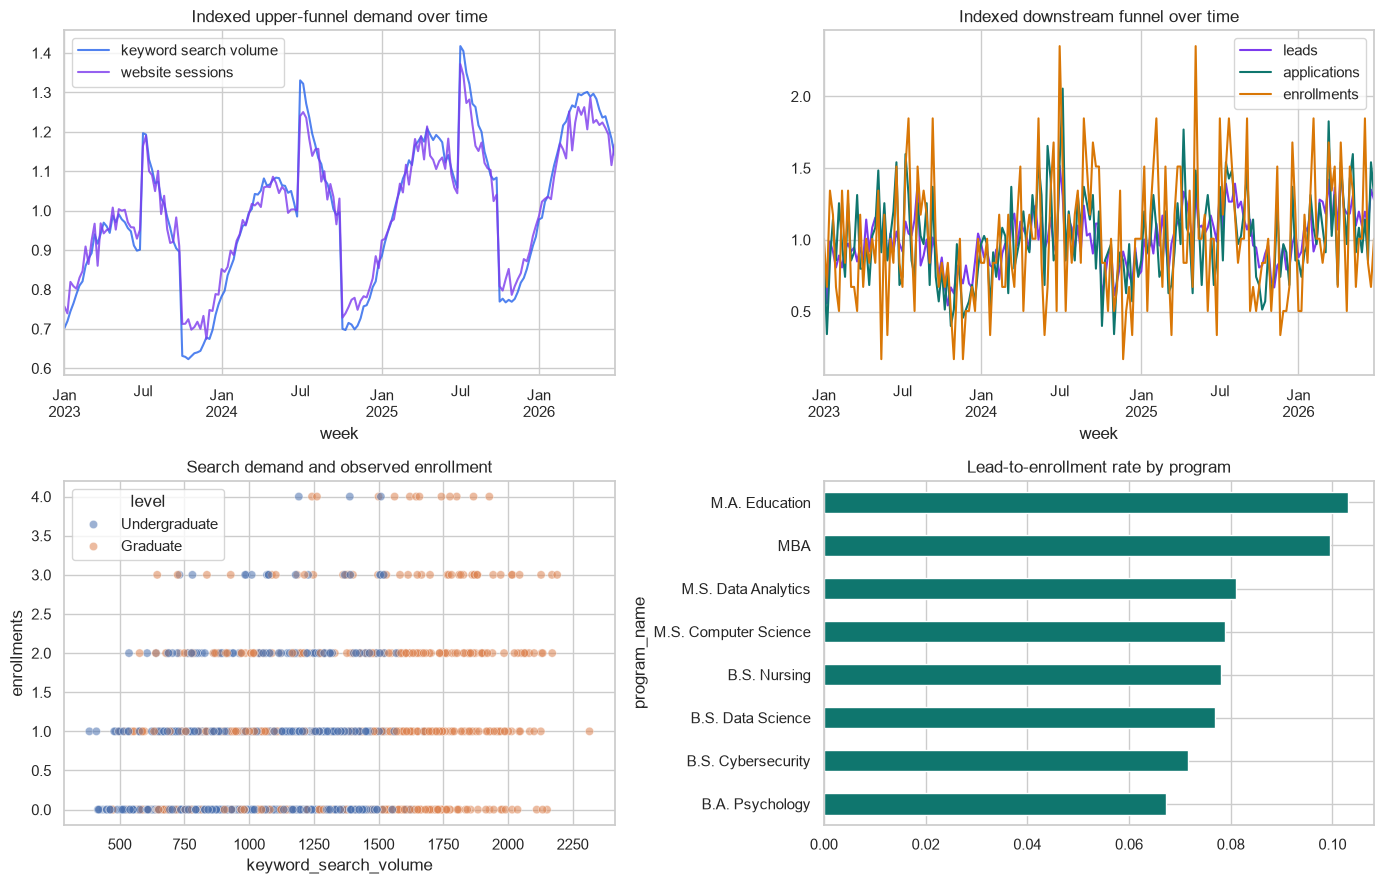

In [6]:
weekly=panel.groupby("week")[["keyword_search_volume","website_sessions","leads","applications","enrollments"]].sum()
fig,axes=plt.subplots(2,2,figsize=(14,9))
for c,color in zip(["keyword_search_volume","website_sessions"],COLORS):
    (weekly[c]/weekly[c].mean()).plot(ax=axes[0,0],label=c.replace("_"," "),color=color,alpha=.8)
axes[0,0].set_title("Indexed upper-funnel demand over time"); axes[0,0].legend()
for c,color in zip(["leads","applications","enrollments"],COLORS[1:]):
    (weekly[c]/weekly[c].mean()).plot(ax=axes[0,1],label=c,color=color)
axes[0,1].set_title("Indexed downstream funnel over time"); axes[0,1].legend()
sns.scatterplot(data=panel,x="keyword_search_volume",y="enrollments",hue="level",alpha=.55,ax=axes[1,0])
axes[1,0].set_title("Search demand and observed enrollment")
program_rates=(panel.groupby("program_name").agg(leads=("leads","sum"),applications=("applications","sum"),
    admits=("admits","sum"),enrollments=("enrollments","sum")))
program_rates["lead_to_enrollment"]=program_rates.enrollments/program_rates.leads
program_rates.lead_to_enrollment.sort_values().plot.barh(ax=axes[1,1],color=COLORS[2])
axes[1,1].set_title("Lead-to-enrollment rate by program")
plt.tight_layout(); plt.show()

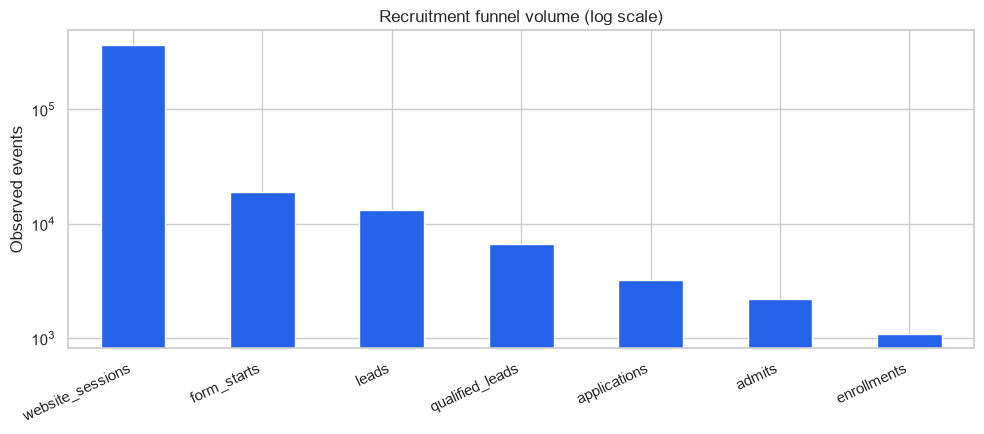

,rate
Session → form start,5.13%
Form start → lead,69.83%
Lead → application,24.39%
Application → admit,69.16%
Admit → enrollment,49.14%


In [7]:
funnel_totals=panel[["website_sessions","form_starts","leads","qualified_leads","applications","admits","enrollments"]].sum()
fig,ax=plt.subplots(figsize=(10,4.5))
funnel_totals.plot.bar(ax=ax,color=COLORS[0])
ax.set_yscale("log"); ax.set_title("Recruitment funnel volume (log scale)"); ax.set_ylabel("Observed events")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.show()

rates=pd.Series({
    "Session → form start":panel.form_starts.sum()/panel.website_sessions.sum(),
    "Form start → lead":panel.leads.sum()/panel.form_starts.sum(),
    "Lead → application":panel.applications.sum()/panel.leads.sum(),
    "Application → admit":panel.admits.sum()/panel.applications.sum(),
    "Admit → enrollment":panel.enrollments.sum()/panel.admits.sum(),
})
display(rates.to_frame("rate").style.format("{:.2%}"))

## 7. Target and Leakage-Safe Feature Engineering

The target is shifted **four weeks backward within each program**: a row observed at week `t` receives enrollment from `t+4`. Current-week search, web, and CRM stages are valid because they are known at the cutoff; future funnel stages are not.

Feature techniques:

- **Ratios:** CTR, engagement rate, form completion, lead-to-application rate, and cost per lead.
- **Lags:** prior program enrollments and funnel activity.
- **Rolling features:** trailing 4- and 13-week averages and trend.
- **Seasonality:** week-of-year sine/cosine and intake months.
- **Interactions:** program level × search demand and paid/organic mix.

In [8]:
panel=panel.sort_values(["program_id","week"]).reset_index(drop=True)
g=panel.groupby("program_id",sort=False)
panel["target_enrollments_4w"]=g.enrollments.shift(-4)
panel["ctr"]=panel.google_clicks/panel.google_impressions.clip(lower=1)
panel["engagement_rate"]=panel.engaged_sessions/panel.website_sessions.clip(lower=1)
panel["form_completion_rate"]=panel.leads/panel.form_starts.clip(lower=1)
panel["lead_to_application_rate"]=panel.applications/panel.leads.clip(lower=1)
panel["cost_per_lead"]=panel.paid_search_spend/panel.leads.clip(lower=1)
panel["paid_click_share"]=panel.google_clicks/(panel.google_clicks+panel.organic_clicks).clip(lower=1)
for c in ["keyword_search_volume","website_sessions","leads","applications","enrollments"]:
    panel[f"{c}_lag_1"]=g[c].shift(1)
    panel[f"{c}_ma_4"]=(g[c].shift(1).groupby(panel.program_id).rolling(4,min_periods=4).mean().reset_index(level=0,drop=True))
panel["enrollments_ma_13"]=(g.enrollments.shift(1).groupby(panel.program_id).rolling(13,min_periods=13).mean().reset_index(level=0,drop=True))
panel["search_trend_4w"]=panel.keyword_search_volume/panel.keyword_search_volume_ma_4.clip(lower=1)-1
week_of_year=panel.week.dt.isocalendar().week.astype(int)
panel["week_sin"]=np.sin(2*np.pi*week_of_year/52)
panel["week_cos"]=np.cos(2*np.pi*week_of_year/52)
panel["intake_season"]=panel.week.dt.month.isin([1,5,8,9]).astype(int)
model_data=panel.dropna(subset=["target_enrollments_4w","enrollments_ma_13"]).copy()
print(f"Model-ready rows: {len(model_data):,}; target mean: {model_data.target_enrollments_4w.mean():.2f}")

Model-ready rows: 1,328; target mean: 0.75


## 8. Staged Feature Sets

Feature-set ablation answers a business question: **how much earlier signal comes from each funnel layer?**

1. Seasonality + historical enrollment baseline
2. Add Google keyword and search-media demand
3. Add website behavior
4. Add leads and applications available at the cutoff

This is more actionable than reporting a single model because it quantifies the predictive contribution and timing of each data layer.

In [9]:
base=["weekly_capacity","annual_tuition","enrollments_lag_1","enrollments_ma_4","enrollments_ma_13","week_sin","week_cos","intake_season"]
search=["keyword_search_volume","branded_search_share","google_impressions","google_clicks","organic_clicks",
        "paid_search_spend","ctr","paid_click_share","keyword_search_volume_lag_1","keyword_search_volume_ma_4","search_trend_4w"]
web=["website_sessions","engaged_sessions","program_page_views","return_visitors","form_starts",
     "engagement_rate","website_sessions_lag_1","website_sessions_ma_4"]
crm=["leads","qualified_leads","applications","cost_per_lead","form_completion_rate","lead_to_application_rate",
     "leads_lag_1","leads_ma_4","applications_lag_1","applications_ma_4"]
categorical=["program_id","level"]
feature_sets={
    "History only":base,
    "+ Search demand":base+search,
    "+ Website behavior":base+search+web,
    "+ Leads & applications":base+search+web+crm,
}
display(pd.DataFrame({"feature_set":feature_sets.keys(),"numeric_features":[len(v) for v in feature_sets.values()]}))

,feature_set,numeric_features
0,History only,8
1,+ Search demand,19
2,+ Website behavior,27
3,+ Leads & applications,37


## 9. Time-Based Train/Test Split

The latest 26 weeks form the untouched holdout. Rows from the same calendar week remain together across programs. Random splitting would let future seasonal patterns inform the past and produce optimistic results.

In [10]:
test_start=model_data.week.max()-pd.Timedelta(weeks=25)
train=model_data[model_data.week<test_start].copy()
test=model_data[model_data.week>=test_start].copy()
assert train.week.max()<test.week.min()
print("Train:",train.week.min().date(),"to",train.week.max().date(),f"({len(train)} rows)")
print("Test: ",test.week.min().date(),"to",test.week.max().date(),f"({len(test)} rows)")

Train: 2023-04-03 to 2025-12-01 (1120 rows)
Test:  2025-12-08 to 2026-06-01 (208 rows)


## 10. Evaluation Metrics

### Technical model metrics

- **MAE:** average absolute miss in students; primary unit-based metric.
- **RMSE:** penalizes large program-week misses more heavily.
- **R²:** variance explained relative to predicting the mean; contextual, not sufficient alone.
- **WAPE:** total absolute error divided by total enrollment; portfolio-friendly and scale aware.
- **Bias:** signed total forecast error divided by actual enrollment; detects systematic under- or overforecasting.
- **80% interval coverage:** percentage of actual outcomes inside the interval; evaluates uncertainty quality.

### Business outcome metrics

- Forecast error reduction versus a four-week seasonal/history baseline
- Programs within ±2 students and ±20% of actual enrollment
- Capacity-risk precision/recall for weeks likely to exceed seats
- Under-capacity and over-capacity planning cost
- Earlier-warning lead time and stability of program rankings
- Incremental enrollments, tuition contribution, cost per incremental enrollment, and ROI in a controlled intervention test

In [11]:
def metrics(actual,predicted):
    a,p=np.asarray(actual),np.clip(np.asarray(predicted),0,None)
    return {"MAE":mean_absolute_error(a,p),"RMSE":mean_squared_error(a,p)**.5,
            "R2":r2_score(a,p),"WAPE":np.abs(a-p).sum()/np.abs(a).sum(),
            "Bias":(p-a).sum()/np.abs(a).sum(),
            "Within ±2":np.mean(np.abs(a-p)<=2),
            "Within ±20%":np.mean(np.abs(a-p)<=np.maximum(.2*a,1))}

## 11. Baselines and Feature-Set Experiment

The operational baseline predicts future enrollment from the trailing four-week program average. Ridge regression provides a transparent regularized model. Each successive experiment uses the same holdout and adds one funnel layer.

In [12]:
y_train=train.target_enrollments_4w; y_test=test.target_enrollments_4w
baseline_pred=test.enrollments_ma_4
experiment_rows=[]; experiment_models={}; experiment_predictions={}
experiment_rows.append({"Feature set":"Trailing 4-week baseline",**metrics(y_test,baseline_pred)})

for name,num_features in feature_sets.items():
    prep=ColumnTransformer([("num",StandardScaler(),num_features),
                            ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical)])
    pipe=Pipeline([("prep",prep),("model",Ridge(alpha=8.0))])
    cols=num_features+categorical
    pipe.fit(train[cols],y_train)
    pred=np.clip(pipe.predict(test[cols]),0,None)
    experiment_models[name]=pipe; experiment_predictions[name]=pred
    experiment_rows.append({"Feature set":name,**metrics(y_test,pred)})
ablation=pd.DataFrame(experiment_rows).set_index("Feature set")
display(ablation.style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.3f}","WAPE":"{:.2%}","Bias":"{:.2%}","Within ±2":"{:.1%}","Within ±20%":"{:.1%}"}))

,MAE,RMSE,R2,WAPE,Bias,Within ±2,Within ±20%
Feature set,,,,,,,
Trailing 4-week baseline,0.71,0.94,-0.107,86.32%,-3.68%,97.1%,82.2%
History only,0.67,0.84,0.113,82.07%,-8.15%,96.6%,81.7%
+ Search demand,0.68,0.84,0.112,82.94%,4.46%,97.1%,81.2%
+ Website behavior,0.68,0.84,0.118,82.78%,4.36%,97.1%,80.8%
+ Leads & applications,0.68,0.85,0.110,83.52%,6.11%,97.1%,83.7%


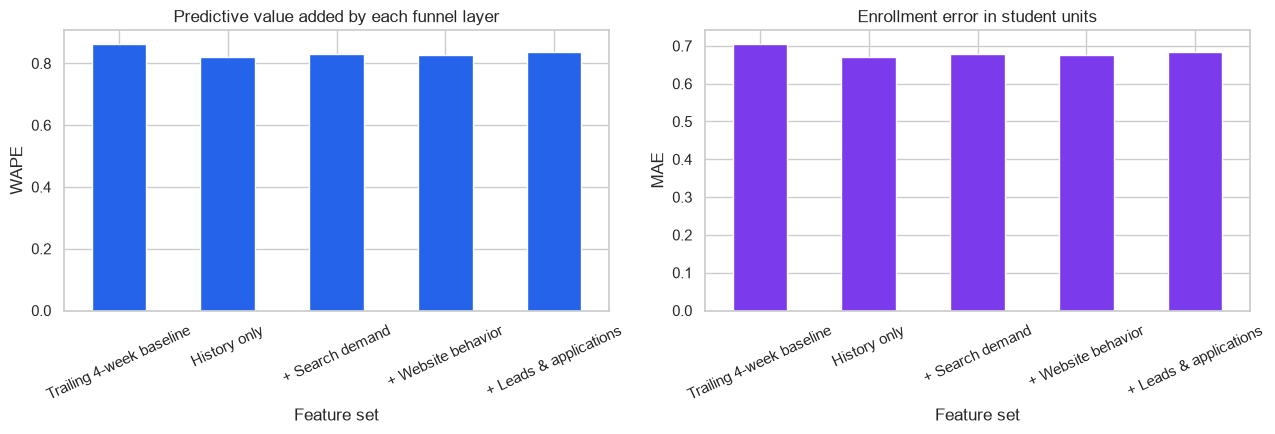

In [13]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
ablation.WAPE.plot.bar(ax=axes[0],color=COLORS[0]); axes[0].set_title("Predictive value added by each funnel layer"); axes[0].set_ylabel("WAPE")
ablation.MAE.plot.bar(ax=axes[1],color=COLORS[1]); axes[1].set_title("Enrollment error in student units"); axes[1].set_ylabel("MAE")
for ax in axes: ax.tick_params(axis="x",rotation=25)
plt.tight_layout(); plt.show()

## 12. Candidate Models

- **Ridge regression:** stable, transparent linear baseline with shrinkage.
- **Random Forest:** captures nonlinearities and interactions through averaged trees.
- **Histogram gradient boosting:** sequentially corrects residuals and is efficient on tabular data.

XGBoost, LightGBM, and CatBoost are strong production candidates when their additional dependencies and governance are justified. Neural networks are not automatically preferable for a small panel dataset.

In [14]:
all_numeric=feature_sets["+ Leads & applications"]
all_features=all_numeric+categorical
prep_all=ColumnTransformer([("num",StandardScaler(),all_numeric),
                            ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical)])
models={
    "Ridge":Ridge(alpha=8),
    "Random Forest":RandomForestRegressor(n_estimators=300,min_samples_leaf=5,max_features=.7,n_jobs=1,random_state=RANDOM_STATE),
    "Gradient Boosting":HistGradientBoostingRegressor(max_iter=220,learning_rate=.055,max_leaf_nodes=15,l2_regularization=2,random_state=RANDOM_STATE),
}
model_rows=[]; fitted={}; predictions={}
for name,estimator in models.items():
    pipe=Pipeline([("prep",prep_all),("model",estimator)])
    start=perf_counter(); pipe.fit(train[all_features],y_train); seconds=perf_counter()-start
    pred=np.clip(pipe.predict(test[all_features]),0,None)
    fitted[name]=pipe; predictions[name]=pred
    model_rows.append({"Model":name,**metrics(y_test,pred),"Fit seconds":seconds})
model_results=pd.DataFrame(model_rows).set_index("Model").sort_values("WAPE")
display(model_results.style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.3f}","WAPE":"{:.2%}","Bias":"{:.2%}","Within ±2":"{:.1%}","Within ±20%":"{:.1%}","Fit seconds":"{:.2f}"}))

,MAE,RMSE,R2,WAPE,Bias,Within ±2,Within ±20%,Fit seconds
Model,,,,,,,,
Ridge,0.68,0.85,0.110,83.52%,6.11%,97.1%,83.7%,0.02
Random Forest,0.70,0.87,0.060,85.13%,14.01%,97.6%,80.3%,4.26
Gradient Boosting,0.73,0.91,-0.031,89.34%,13.12%,98.1%,75.0%,0.94


## 13. Expanding-Window Cross-Validation and Tuning

Cross-validation must preserve calendar order. Each fold trains on earlier weeks and validates on later weeks. Randomized search tunes learning rate, leaf count, regularization, and iterations using negative MAE. The final test period remains untouched.

In [15]:
ordered=train.sort_values("week").reset_index(drop=True)
unique_weeks=ordered.week.drop_duplicates().sort_values().to_numpy()
folds=[]
for tr_i,va_i in TimeSeriesSplit(n_splits=4).split(unique_weeks):
    tr_weeks,va_weeks=set(unique_weeks[tr_i]),set(unique_weeks[va_i])
    folds.append((ordered.index[ordered.week.isin(tr_weeks)].to_numpy(),ordered.index[ordered.week.isin(va_weeks)].to_numpy()))
tune=Pipeline([("prep",prep_all),("model",HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
search=RandomizedSearchCV(tune,{
    "model__learning_rate":[.025,.04,.06,.09],"model__max_leaf_nodes":[7,12,18,28],
    "model__min_samples_leaf":[10,20,35,55],"model__l2_regularization":[0,.5,2,5],
    "model__max_iter":[140,220,320]},n_iter=12,scoring="neg_mean_absolute_error",cv=folds,
    random_state=RANDOM_STATE,n_jobs=1,refit=True)
search.fit(ordered[all_features],ordered.target_enrollments_4w)
print("Best expanding-window CV MAE:",round(-search.best_score_,3))
print("Best parameters:",search.best_params_)

Best expanding-window CV MAE: 0.731
Best parameters: {'model__min_samples_leaf': 55, 'model__max_leaf_nodes': 18, 'model__max_iter': 320, 'model__learning_rate': 0.04, 'model__l2_regularization': 5}


## 14. Final Holdout Evaluation

,MAE,RMSE,R2,WAPE,Bias,Within ±2,Within ±20%
Seasonal/history baseline,0.71,0.94,-0.107,86.32%,-3.68%,97.1%,82.2%
Tuned gradient boosting,0.72,0.88,0.027,88.30%,14.50%,97.6%,76.0%


WAPE improvement: -2.3%


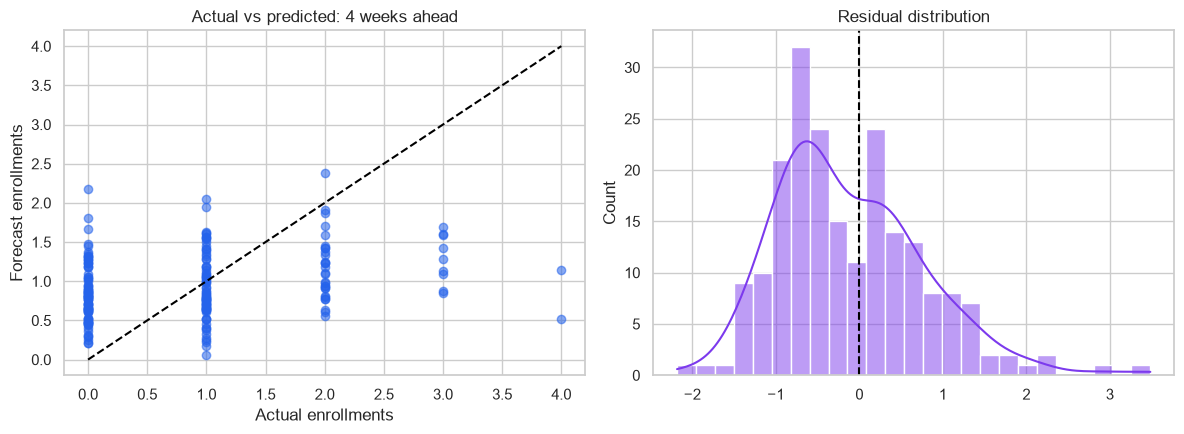

In [16]:
best_model=search.best_estimator_
forecast=np.clip(best_model.predict(test[all_features]),0,None)
final_metrics=metrics(y_test,forecast)
comparison=pd.DataFrame({"Seasonal/history baseline":metrics(y_test,baseline_pred),
                         "Tuned gradient boosting":final_metrics}).T
display(comparison.style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.3f}","WAPE":"{:.2%}","Bias":"{:.2%}","Within ±2":"{:.1%}","Within ±20%":"{:.1%}"}))
print(f"WAPE improvement: {1-final_metrics['WAPE']/comparison.loc['Seasonal/history baseline','WAPE']:.1%}")

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(y_test,forecast,alpha=.55,color=COLORS[0]); lim=max(y_test.max(),forecast.max()); axes[0].plot([0,lim],[0,lim],"--",color="black")
axes[0].set(xlabel="Actual enrollments",ylabel="Forecast enrollments",title="Actual vs predicted: 4 weeks ahead")
residual=y_test.to_numpy()-forecast
sns.histplot(residual,bins=25,kde=True,ax=axes[1],color=COLORS[1]); axes[1].axvline(0,color="black",linestyle="--")
axes[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

## 15. Program-Level Diagnostics and Forecast Intervals

Aggregate accuracy can hide systematic errors in small or high-growth programs. Review WAPE, MAE, and bias by program. A simple empirical residual interval provides a baseline uncertainty range; production intervals should be calibrated by program, horizon, and season.

In [17]:
scored=test[["week","program_id","program_name","level","weekly_capacity","annual_tuition","target_enrollments_4w"]].copy()
scored["forecast"]=forecast; scored["error"]=scored.target_enrollments_4w-scored.forecast
q10,q90=np.quantile(scored.error,[.10,.90])
scored["lower_80"]=np.clip(scored.forecast+q10,0,None); scored["upper_80"]=scored.forecast+q90
coverage=scored.target_enrollments_4w.between(scored.lower_80,scored.upper_80).mean()
by_program=scored.groupby("program_name").apply(lambda d:pd.Series(metrics(d.target_enrollments_4w,d.forecast)))
display(by_program.sort_values("WAPE").style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.3f}","WAPE":"{:.2%}","Bias":"{:.2%}","Within ±2":"{:.1%}","Within ±20%":"{:.1%}"}))
print(f"Empirical 80% interval coverage: {coverage:.1%}")

,MAE,RMSE,R2,WAPE,Bias,Within ±2,Within ±20%
program_name,,,,,,,
MBA,0.95,1.14,-0.184,63.27%,-0.57%,92.3%,57.7%
M.S. Computer Science,0.71,0.87,0.134,63.86%,4.59%,96.2%,80.8%
M.A. Education,0.62,0.73,-0.042,73.17%,-17.47%,100.0%,76.9%
B.S. Cybersecurity,0.77,0.95,-0.209,90.94%,11.14%,96.2%,69.2%
M.S. Data Analytics,0.74,0.88,-0.205,96.71%,27.48%,100.0%,73.1%
B.S. Nursing,0.60,0.72,-0.100,104.82%,28.52%,100.0%,80.8%
B.S. Data Science,0.79,1.02,-0.223,128.58%,48.23%,96.2%,76.9%
B.A. Psychology,0.58,0.65,-0.548,216.83%,106.28%,100.0%,92.3%


Empirical 80% interval coverage: 79.8%


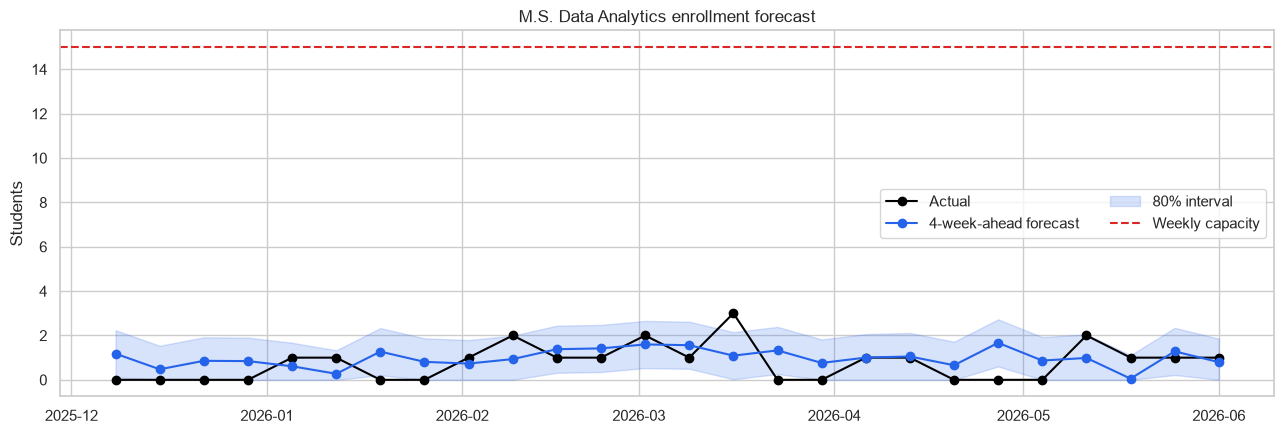

In [18]:
example=scored.query("program_id == 'MS-DA'").sort_values("week")
fig,ax=plt.subplots(figsize=(13,4.5))
ax.plot(example.week,example.target_enrollments_4w,label="Actual",color="black",marker="o")
ax.plot(example.week,example.forecast,label="4-week-ahead forecast",color=COLORS[0],marker="o")
ax.fill_between(example.week,example.lower_80,example.upper_80,color=COLORS[0],alpha=.18,label="80% interval")
ax.axhline(example.weekly_capacity.iloc[0],color=COLORS[4],linestyle="--",label="Weekly capacity")
ax.set(title="M.S. Data Analytics enrollment forecast",ylabel="Students"); ax.legend(ncol=2)
plt.tight_layout(); plt.show()

## 16. Interpretation

Permutation importance measures the increase in holdout error when a feature is shuffled. Partial dependence visualizes the model's average response to a feature. SHAP could provide local program-week attributions. These explain predictive associations, not the causal return from adding search spend.

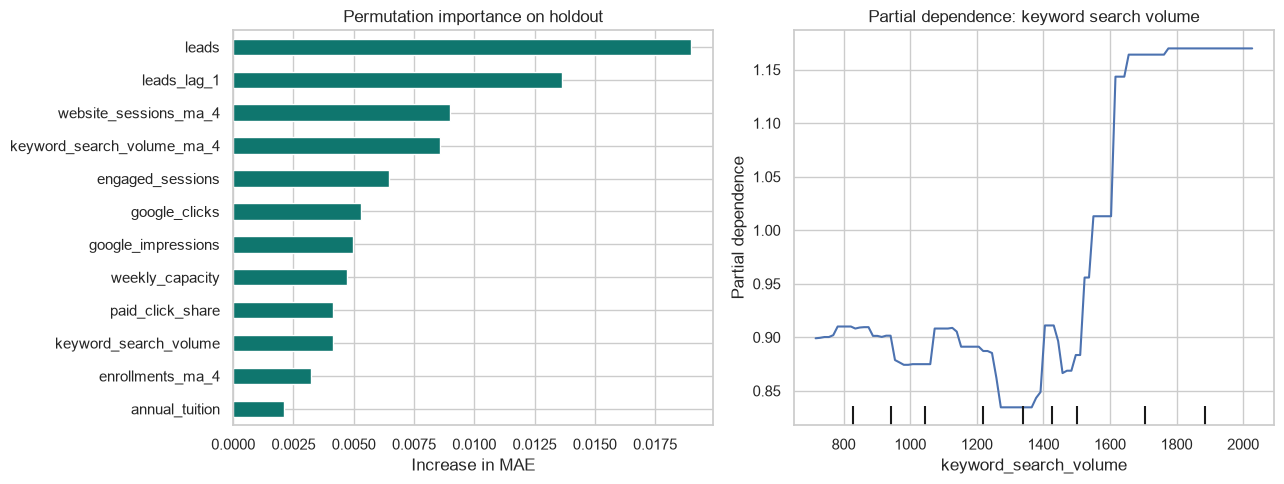

In [19]:
perm=permutation_importance(best_model,test[all_features],y_test,scoring="neg_mean_absolute_error",
                            n_repeats=8,random_state=RANDOM_STATE,n_jobs=1)
importance=pd.Series(perm.importances_mean,index=all_features).sort_values(ascending=False)
fig,axes=plt.subplots(1,2,figsize=(13,5))
importance.head(12).sort_values().plot.barh(ax=axes[0],color=COLORS[2]); axes[0].set_title("Permutation importance on holdout"); axes[0].set_xlabel("Increase in MAE")
X_pdp=test[all_features].copy(); X_pdp["keyword_search_volume"]=X_pdp.keyword_search_volume.astype(float)
PartialDependenceDisplay.from_estimator(best_model,X_pdp,["keyword_search_volume"],kind="average",ax=axes[1])
axes[1].set_title("Partial dependence: keyword search volume")
plt.tight_layout(); plt.show()

## 17. Business Outcome Evaluation

Translate forecasts into decisions. This example evaluates:

- **Planning accuracy:** share of program-weeks within ±2 students.
- **Capacity-risk detection:** whether future enrollment will exceed weekly planned seats.
- **Planning cost:** under-capacity penalty is larger than excess-capacity cost.
- **Tuition-at-risk visibility:** forecasted demand above capacity × annual tuition.

Costs are illustrative; finance and academic operations should set real values.

In [20]:
actual_over=scored.target_enrollments_4w>scored.weekly_capacity
pred_over=scored.forecast>scored.weekly_capacity
tp=np.sum(actual_over&pred_over); fp=np.sum(~actual_over&pred_over); fn=np.sum(actual_over&~pred_over)
capacity_precision=tp/max(tp+fp,1); capacity_recall=tp/max(tp+fn,1)

def planning_cost(actual,plan,under_cost=4500,over_cost=900):
    return (np.maximum(actual-plan,0)*under_cost+np.maximum(plan-actual,0)*over_cost).sum()
business=pd.Series({
    "Program-weeks within ±2 students":np.mean(np.abs(scored.target_enrollments_4w-scored.forecast)<=2),
    "Capacity-risk precision":capacity_precision,
    "Capacity-risk recall":capacity_recall,
    "Baseline planning cost":planning_cost(y_test,baseline_pred),
    "Model planning cost":planning_cost(y_test,forecast),
    "Planning cost reduction":1-planning_cost(y_test,forecast)/planning_cost(y_test,baseline_pred),
})
display(business.to_frame("value"))

risk=(scored.groupby("program_name").agg(actual=("target_enrollments_4w","sum"),forecast=("forecast","sum"),
       weekly_capacity=("weekly_capacity","sum"),annual_tuition=("annual_tuition","first")))
risk["forecast_above_capacity"]=np.maximum(risk.forecast-risk.weekly_capacity,0)
risk["tuition_demand_above_capacity"]=risk.forecast_above_capacity*risk.annual_tuition
display(risk.sort_values("tuition_demand_above_capacity",ascending=False).style.format({"tuition_demand_above_capacity":"${:,.0f}"}))

,value
Program-weeks within ±2 students,0.975962
Capacity-risk precision,0.000000
Capacity-risk recall,0.000000
Baseline planning cost,407475.000000
Model planning cost,360948.222405
Planning cost reduction,0.114183


,actual,forecast,weekly_capacity,annual_tuition,forecast_above_capacity,tuition_demand_above_capacity
program_name,,,,,,
B.A. Psychology,7.000000,14.439685,494,25000,0.000000,$0
B.S. Cybersecurity,22.000000,24.451228,390,28500,0.000000,$0
B.S. Data Science,16.000000,23.716417,468,28000,0.000000,$0
B.S. Nursing,15.000000,19.277796,520,30000,0.000000,$0
M.A. Education,22.000000,18.157610,442,22000,0.000000,$0
M.S. Computer Science,29.000000,30.329659,416,26000,0.000000,$0
M.S. Data Analytics,20.000000,25.495672,390,24500,0.000000,$0
MBA,39.000000,38.775956,572,31000,0.000000,$0


## 18. Deployment and Weekly Decision Workflow

1. Snapshot search, media, GA4, CRM, and enrollment sources at the weekly cutoff.
2. Validate freshness, program mapping, funnel ordering, and schema.
3. Build cutoff-safe features in the warehouse.
4. Score each program for `t+4`, attach 80% intervals, and flag capacity risk.
5. Publish a governed table and dashboard to admissions, marketing, and academic operations.
6. Store forecasts before outcomes arrive so evaluation is auditable.

Use batch deployment because the decision refreshes weekly. Version model, features, source snapshots, cutoff time, program mapping, and forecast horizon together.

In [21]:
contract={
    "model":"program_enrollment_4_week_forecast","version":"1.0.0","grain":["observation_week","program_id"],
    "horizon_weeks":4,"refresh":"weekly","cutoff":"Monday 05:00 UTC",
    "outputs":["forecast","lower_80","upper_80","capacity_risk","model_version"],
    "owners":{"data":"analytics engineering","model":"data science","decision":"enrollment management"},
}
print(json.dumps(contract,indent=2))

{
  "model": "program_enrollment_4_week_forecast",
  "version": "1.0.0",
  "grain": [
    "observation_week",
    "program_id"
  ],
  "horizon_weeks": 4,
  "refresh": "weekly",
  "cutoff": "Monday 05:00 UTC",
  "outputs": [
    "forecast",
    "lower_80",
    "upper_80",
    "capacity_risk",
    "model_version"
  ],
  "owners": {
    "data": "analytics engineering",
    "model": "data science",
    "decision": "enrollment management"
  }
}


## 19. Monitoring and Retraining

Monitor four layers:

- **Data:** freshness, missingness, program mapping, funnel ordering, and volume anomalies.
- **Drift:** search mix, branded share, sessions, leads, applications, and forecast distribution.
- **Performance:** MAE, WAPE, bias, interval coverage, and capacity-risk precision/recall after outcomes arrive.
- **Business:** planning-cost reduction, response time, target attainment, incremental enrollment, and ROI.

Retrain on a schedule aligned with enrollment cycles or after sustained performance drift. A challenger should beat the champion in rolling-origin validation and important program segments before promotion.

,MAE,RMSE,R2,WAPE,Bias,Within ±2,Within ±20%
period,,,,,,,
Early holdout,0.69,0.83,0.148,82.13%,7.85%,98.1%,76.9%
Late holdout,0.76,0.93,-0.096,94.77%,21.46%,97.1%,75.0%


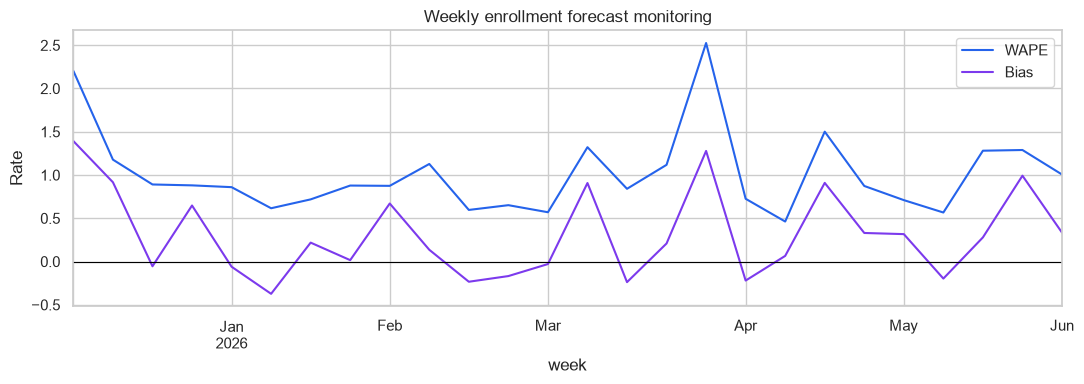

In [22]:
scored["period"]=np.where(scored.week<scored.week.min()+pd.Timedelta(weeks=13),"Early holdout","Late holdout")
monitor=scored.groupby("period").apply(lambda d:pd.Series(metrics(d.target_enrollments_4w,d.forecast)))
display(monitor.style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.3f}","WAPE":"{:.2%}","Bias":"{:.2%}","Within ±2":"{:.1%}","Within ±20%":"{:.1%}"}))

weekly_monitor=scored.groupby("week").apply(lambda d:pd.Series({
    "WAPE":np.abs(d.target_enrollments_4w-d.forecast).sum()/d.target_enrollments_4w.sum(),
    "Bias":(d.forecast-d.target_enrollments_4w).sum()/d.target_enrollments_4w.sum()}))
weekly_monitor.plot(figsize=(11,4),color=COLORS[:2]); plt.axhline(0,color="black",linewidth=.8)
plt.title("Weekly enrollment forecast monitoring"); plt.ylabel("Rate"); plt.tight_layout(); plt.show()

## 20. Experimentation and Incrementality

The model identifies where enrollment is likely, not where marketing will create enrollment. To validate action:

- Randomize eligible programs, geographies, or keyword clusters to model-guided budget versus business-as-usual.
- Pre-register spend constraints, treatment rules, primary outcomes, and duration.
- Measure **incremental enrollments**, **incremental tuition contribution**, **cost per incremental enrollment**, and **ROI**.
- Include guardrails: lead quality, application completion, program mix, equity, and counselor workload.

When randomization is impossible, use carefully justified causal methods such as difference-in-differences or geo experiments. Never label forecast importance as media incrementality.

In [23]:
experiment_plan=pd.DataFrame({
    "Component":["Unit","Treatment","Control","Primary outcome","Financial outcome","Guardrails","Duration"],
    "Design":["Program × geography or keyword cluster","Model-guided budget and outreach",
              "Business-as-usual allocation","Incremental enrollments","Net tuition contribution and ROI",
              "Lead quality, equity, counselor load, program mix","At least one full recruitment cycle"],
})
display(experiment_plan)

# Business formulas:
# incremental_enrollment = treatment_enrollment - counterfactual_enrollment
# contribution = incremental_enrollment * net_tuition_contribution_per_student
# ROI = (contribution - incremental_marketing_and_service_cost) / incremental_cost

,Component,Design
0,Unit,Program × geography or keyword cluster
1,Treatment,Model-guided budget and outreach
2,Control,Business-as-usual allocation
3,Primary outcome,Incremental enrollments
4,Financial outcome,Net tuition contribution and ROI
5,Guardrails,"Lead quality, equity, counselor load, program mix"
6,Duration,At least one full recruitment cycle


## 21. Recommendations and Limitations

### Recommendations

1. Use the four-week program forecast for planning, while retaining lead-level scoring for individual follow-up prioritization.
2. Govern the query-to-program taxonomy; mapping drift can create false demand shifts.
3. Snapshot mutable CRM stages and enforce feature availability at each historical cutoff.
4. Report staged feature-set results so leaders can see how much signal arrives at search, website, lead, and application stages.
5. Evaluate technical accuracy and business decision quality separately.
6. Publish prediction intervals and capacity-risk flags rather than false point precision.
7. Use controlled experiments before reallocating budget based on predictive associations.

### Limitations

- Synthetic funnel behavior is simpler than real multi-device, multi-campus, offline, and privacy-constrained journeys.
- Observed enrollment may be censored by capacity, admissions policy, aid, or program availability.
- Aggregate program-week models can hide individual heterogeneity.
- Search and media variables are jointly driven by seasonality and budget decisions.
- Production use requires consent, governance, protected-class review, fairness analysis, access controls, and FERPA-aware handling.

### Conclusion

Program-level enrollment prediction is most useful as an early-warning and planning system. Search reveals market demand first, website behavior adds intent, CRM stages add downstream certainty, and time-aware machine learning combines them into an auditable forecast. The final standard of success is not only lower error—it is better, fairer, and experimentally validated enrollment decisions.

## 22. Export Reusable Outputs

In [24]:
OUTPUT_DIR=Path("outputs/program_enrollment_forecasting")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
scored.to_csv(OUTPUT_DIR/"program_week_forecasts.csv",index=False)
ablation.to_csv(OUTPUT_DIR/"funnel_feature_ablation.csv")
model_results.to_csv(OUTPUT_DIR/"model_comparison.csv")
by_program.to_csv(OUTPUT_DIR/"program_diagnostics.csv")
monitor.to_csv(OUTPUT_DIR/"monitoring_snapshot.csv")
with open(OUTPUT_DIR/"deployment_contract.json","w",encoding="utf-8") as f: json.dump(contract,f,indent=2)
for p in sorted(OUTPUT_DIR.iterdir()): print("Created:",p)

Created: outputs\program_enrollment_forecasting\deployment_contract.json
Created: outputs\program_enrollment_forecasting\funnel_feature_ablation.csv
Created: outputs\program_enrollment_forecasting\model_comparison.csv
Created: outputs\program_enrollment_forecasting\monitoring_snapshot.csv
Created: outputs\program_enrollment_forecasting\program_diagnostics.csv
Created: outputs\program_enrollment_forecasting\program_week_forecasts.csv
